# DETR Parking Space Detection

This notebook fine-tunes DETR (Detection Transformer) ResNet50 for parking space detection using the YOLO-formatted dataset.

**Note**: This notebook uses the `transformers` library for DETR implementation as torchvision 0.20.1+cu121 doesn't include DETR.
**Select the kernel**: "Python (detr-env)" to run this notebook with the correct environment.

Features:
- Fine-tunes DETR ResNet50 on 3 classes (free, not_free, partially_free parking spaces)
- Uses existing YOLO-formatted dataset at `data/processed/yolo_parking/`
- Checkpoint saving (best model + periodic checkpoints)
- Early stopping mechanism
- Resume functionality - continue training from checkpoints
- Training and validation loss visualization
- Sample prediction visualization

**Important**: DETR uses `num_classes` = object classes only (no background). DETR adds a "no-object" class internally. So labels must be {0, 1, 2} (same as YOLO, no remapping needed).



## 1. Imports & Path Setup


In [32]:
import os
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt
import random

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Use transformers library for DETR (torchvision 0.20.1 doesn't have DETR)
from transformers import DetrForObjectDetection, DetrImageProcessor

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == "Phase 1" else (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
YOLO_ROOT = BASE_DIR / "data" / "processed" / "yolo_parking"

IMG_TRAIN = YOLO_ROOT / "images" / "train"
IMG_VAL = YOLO_ROOT / "images" / "val"
LBL_TRAIN = YOLO_ROOT / "labels" / "train"
LBL_VAL = YOLO_ROOT / "labels" / "val"

# Checkpoint directory
CHECKPOINT_DIR = BASE_DIR / "checkpoints" / "detr_parking"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("YOLO_ROOT exists:", YOLO_ROOT.exists())
print("Train images dir:", IMG_TRAIN, IMG_TRAIN.exists())
print("Train labels dir:", LBL_TRAIN, LBL_TRAIN.exists())
print("Checkpoint dir:", CHECKPOINT_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


BASE_DIR: c:\Harosha\George Brown\DL2\parking-vision
YOLO_ROOT exists: True
Train images dir: c:\Harosha\George Brown\DL2\parking-vision\data\processed\yolo_parking\images\train True
Train labels dir: c:\Harosha\George Brown\DL2\parking-vision\data\processed\yolo_parking\labels\train True
Checkpoint dir: c:\Harosha\George Brown\DL2\parking-vision\checkpoints\detr_parking
Using device: cpu


## 2. Class Names & Label Mapping

**Important**: DETR uses `num_classes` = object classes only (no background). DETR adds a "no-object" class internally. So labels must be {0, 1, 2} (same as YOLO, no remapping needed).


In [33]:
# YOLO-style class names from data.yaml
class_names = [
    "free_parking_space",
    "not_free_parking_space",
    "partially_free_parking_space",
]

num_classes_detr = len(class_names)  # DETR: object classes only (no background)

print("Classes:", class_names)
print("num_classes_detr (for DETR):", num_classes_detr)
print("\nNote: DETR adds 'no-object' class internally, so labels must be {0, 1, 2}")

# YOLO class ids (0,1,2) -> DETR labels (0,1,2), NO background index here
# Actually, same mapping - no remapping needed!
yolo_to_detr = {0: 0, 1: 1, 2: 2}

print("\nLabel mapping (same as YOLO):")
print("YOLO class 0 -> DETR class 0 (free_parking_space)")
print("YOLO class 1 -> DETR class 1 (not_free_parking_space)")
print("YOLO class 2 -> DETR class 2 (partially_free_parking_space)")


Classes: ['free_parking_space', 'not_free_parking_space', 'partially_free_parking_space']
num_classes_detr (for DETR): 3

Note: DETR adds 'no-object' class internally, so labels must be {0, 1, 2}

Label mapping (same as YOLO):
YOLO class 0 -> DETR class 0 (free_parking_space)
YOLO class 1 -> DETR class 1 (not_free_parking_space)
YOLO class 2 -> DETR class 2 (partially_free_parking_space)


## 3. Load DETR Model & Image Processor

We use the `transformers` library's DETR implementation since torchvision 0.20.1 doesn't include DETR.


In [34]:
# Load DETR model and processor from transformers
# Using Facebook's DETR ResNet-50 as base model
model_name = "facebook/detr-resnet-50"

# Configure processor to resize images consistently
processor = DetrImageProcessor.from_pretrained(
    model_name,
    size={"shortest_edge": 800, "longest_edge": 1333},  # Standard DETR size
    do_resize=True,
    do_normalize=True,
    do_rescale=True,
)

# Load config and modify num_labels before loading the model
# This ensures the loss function is initialized correctly with the new number of classes
from transformers import DetrConfig

config = DetrConfig.from_pretrained(model_name)
num_labels = num_classes_detr + 1  # +1 for background/no-object class
config.num_labels = num_labels

# Load model with modified config, ignoring mismatched head sizes
# This loads the pretrained backbone weights but initializes the classification head
# with the correct number of classes, and the loss function uses the updated config
detr_model = DetrForObjectDetection.from_pretrained(
    model_name,
    config=config,
    ignore_mismatched_sizes=True  # Allows loading backbone but reinitializing head
)

detr_model = detr_model.to(device)
detr_model.train()

print("DETR Model loaded and configured")
print(f"Total parameters: {sum(p.numel() for p in detr_model.parameters() if p.requires_grad):,}")
print(f"num_classes={num_classes_detr} (DETR will add 'no-object' class internally)")


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

DETR Model loaded and configured
Total parameters: 41,280,009
num_classes=3 (DETR will add 'no-object' class internally)


## 4. Custom Dataset for YOLO -> DETR

Converts YOLO format annotations to DETR format compatible with transformers library.


In [35]:
class YoloDetectionDatasetDetr(Dataset):
    def __init__(self, img_dir: Path, lbl_dir: Path, processor, yolo_to_detr_map: dict):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.processor = processor
        self.yolo_to_detr = yolo_to_detr_map

        # collect image paths
        exts = (".jpg", ".jpeg", ".png")
        self.img_paths = [p for p in sorted(img_dir.rglob("*")) if p.suffix.lower() in exts]

        if len(self.img_paths) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        lbl_path = self.lbl_dir / (img_path.stem + ".txt")

        # Read image as PIL Image (transformers expects PIL)
        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        # Prepare COCO-format annotations for transformers DETR
        coco_annotations = []
        
        if lbl_path.exists():
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_yolo = int(parts[0])
                    xc_n, yc_n, w_n, h_n = map(float, parts[1:])

                    # convert YOLO normalized to pixel coords
                    xc = xc_n * width
                    yc = yc_n * height
                    bw = w_n * width
                    bh = h_n * height

                    x_min = xc - bw / 2.0
                    y_min = yc - bh / 2.0
                    x_max = xc + bw / 2.0
                    y_max = yc + bh / 2.0

                    # clip to image bounds
                    x_min = max(0.0, x_min)
                    y_min = max(0.0, y_min)
                    x_max = min(float(width), x_max)
                    y_max = min(float(height), y_max)

                    if x_max <= x_min or y_max <= y_min:
                        continue

                    # remap class id for DETR (actually same mapping)
                    if cls_yolo not in self.yolo_to_detr:
                        continue
                    cls_detr = self.yolo_to_detr[cls_yolo]

                    # COCO format: bbox is [x_min, y_min, width, height]
                    bbox_width = x_max - x_min
                    bbox_height = y_max - y_min
                    
                    coco_annotations.append({
                        "bbox": [x_min, y_min, bbox_width, bbox_height],
                        "category_id": cls_detr,
                        "area": bbox_width * bbox_height,
                    })

        # Format annotations in COCO format expected by DETR processor
        # Structure: {"image_id": id, "annotations": [list of COCO annotations]}
        target = {
            "image_id": idx,
            "annotations": coco_annotations if len(coco_annotations) > 0 else []
        }

        # Process image and target with DETR processor
        # The processor will resize images to a standard size (800 pixels on longest side by default)
        encoding = self.processor(images=image, annotations=target, return_tensors="pt")
        
        # Keep batch dimension for consistent sizing - we'll handle it in collate
        pixel_values = encoding["pixel_values"][0]  # Remove batch dimension but keep size consistent
        labels = encoding["labels"][0]  # Get first (and only) label dict
        
        return pixel_values, labels

train_dataset = YoloDetectionDatasetDetr(IMG_TRAIN, LBL_TRAIN, processor, yolo_to_detr)
val_dataset = YoloDetectionDatasetDetr(IMG_VAL, LBL_VAL, processor, yolo_to_detr)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


Train samples: 24
Val samples: 6


## 5. DataLoaders


In [36]:
def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    
    # Check sizes and pad if needed
    # Get max dimensions
    max_h = max(pv.shape[1] for pv in pixel_values)
    max_w = max(pv.shape[2] for pv in pixel_values)
    
    # Pad all images to the same size
    # For 3D tensors [C, H, W], pad format is (pad_left, pad_right, pad_top, pad_bottom)
    padded_pixel_values = []
    for pv in pixel_values:
        if pv.shape[1] != max_h or pv.shape[2] != max_w:
            # Calculate padding: pad bottom and right to match max dimensions
            pad_h = max_h - pv.shape[1]
            pad_w = max_w - pv.shape[2]
            # Format: (pad_left, pad_right, pad_top, pad_bottom)
            pv = torch.nn.functional.pad(pv, (0, pad_w, 0, pad_h), mode='constant', value=0)
        padded_pixel_values.append(pv)
    
    # Stack pixel values
    pixel_values = torch.stack(padded_pixel_values)
    
    return pixel_values, labels

BATCH_SIZE = 2  # DETR is memory-intensive; keep batch small

# Note: num_workers=0 on Windows to avoid multiprocessing issues
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Windows compatibility
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Windows compatibility
    collate_fn=collate_fn,
)

# quick sanity check
pixel_values, labels = next(iter(train_loader))
print("Batch pixel_values shape:", pixel_values.shape)
print("Batch labels length:", len(labels))


Batch pixel_values shape: torch.Size([2, 3, 751, 1333])
Batch labels length: 2


## 6. Training Configuration


In [37]:
# Setup optimizer
params = [p for p in detr_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

# Training hyperparameters
NUM_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for this many epochs
MIN_DELTA = 0.001  # Minimum change to qualify as improvement
CHECKPOINT_EVERY = 5  # Save checkpoint every N epochs

print("Training Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Early Stopping Patience: {EARLY_STOPPING_PATIENCE} epochs")
print(f"  Min Delta: {MIN_DELTA}")
print(f"  Checkpoint Every: {CHECKPOINT_EVERY} epochs")


Training Configuration:
  Epochs: 20
  Early Stopping Patience: 10 epochs
  Min Delta: 0.001
  Checkpoint Every: 5 epochs


### 6.1 Optional: Reset Checkpoints (Start Fresh)


In [38]:
# Uncomment the lines below to delete all checkpoints and start fresh
# import shutil
# if CHECKPOINT_DIR.exists():
#     for checkpoint_file in CHECKPOINT_DIR.glob("*.pt"):
#         checkpoint_file.unlink()
#         print(f"Deleted: {checkpoint_file.name}")
#     print("All checkpoints deleted. Training will start from scratch.")
# else:
#     print("No checkpoints directory found.")



Checkpoint reset is disabled. Uncomment the code above to enable.


## 7. Training Functions


In [39]:
def train_one_epoch_detr(model, data_loader, optimizer, device):
    model.train()
    running_loss = 0.0
    num_batches = 0

    for pixel_values, labels in data_loader:
        pixel_values = pixel_values.to(device)
        labels = [{k: v.to(device) for k, v in label.items()} for label in labels]

        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1

    return running_loss / max(1, num_batches)

@torch.no_grad()
def evaluate_detr(model, data_loader, device):
    model.eval()
    running_loss = 0.0
    num_batches = 0

    for pixel_values, labels in data_loader:
        pixel_values = pixel_values.to(device)
        labels = [{k: v.to(device) for k, v in label.items()} for label in labels]

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        running_loss += loss.item()
        num_batches += 1

    return running_loss / max(1, num_batches)

print("Training functions defined")


Training functions defined


## 8. Training Loop with Early Stopping, Checkpoints, and Resume

**Resume Functionality**: If a checkpoint exists, training will automatically resume from the last saved epoch. Simply increase `NUM_EPOCHS` to continue training beyond the checkpoint.


In [40]:
# Initialize training state
start_epoch = 1
best_val_loss = float("inf")
history = {
    "train_loss": [],
    "val_loss": [],
}
patience_counter = 0
best_epoch = 0

# Try to load the best model checkpoint first (most recent training)
best_model_path = CHECKPOINT_DIR / "best_model.pt"
if best_model_path.exists():
    print(f"Found existing checkpoint: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    
    # Load model state
    detr_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Restore training state
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', checkpoint.get('val_loss', float('inf')))
    best_epoch = checkpoint.get('best_epoch', checkpoint['epoch'])
    history = checkpoint.get('history', history)
    patience_counter = checkpoint.get('patience_counter', 0)
    
    print(f"Resuming training from epoch {start_epoch}")
    print(f"Previous best: Val Loss = {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"Previous history: {len(history['train_loss'])} epochs completed")
    
    # If we're already past NUM_EPOCHS, inform user
    if start_epoch > NUM_EPOCHS:
        print(f"\nNote: Checkpoint is at epoch {start_epoch-1}, but NUM_EPOCHS={NUM_EPOCHS}.")
        print("Increase NUM_EPOCHS to continue training beyond the checkpoint.")
else:
    print("No existing checkpoint found. Starting fresh training.")

start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    train_loss = train_one_epoch_detr(detr_model, train_loader, optimizer, device)
    val_loss = evaluate_detr(detr_model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Check for improvement
    improved = False
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        improved = True
        
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': detr_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch,
            'patience_counter': patience_counter,
            'history': history,
        }, best_model_path)
        print(f"  -> New best model saved! (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1

    # Save periodic checkpoint
    if epoch % CHECKPOINT_EVERY == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': detr_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'history': history,
            'best_epoch': best_epoch,
        }, checkpoint_path)
        print(f"  -> Checkpoint saved: {checkpoint_path.name}")

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}{' *' if improved else ''}")

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered! No improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
        break

end_time = time.time()
print(f"\nTraining finished in {(end_time - start_time)/60:.2f} minutes.")
print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")


No existing checkpoint found. Starting fresh training.
  -> New best model saved! (Val Loss: 3.6353)
Epoch [1/20] Train Loss: 3.5551 | Val Loss: 3.6353 *
  -> New best model saved! (Val Loss: 3.2222)
Epoch [2/20] Train Loss: 2.9908 | Val Loss: 3.2222 *
Epoch [3/20] Train Loss: 3.0820 | Val Loss: 3.2912
Epoch [4/20] Train Loss: 2.7549 | Val Loss: 3.3091
  -> New best model saved! (Val Loss: 3.0517)
  -> Checkpoint saved: checkpoint_epoch_5.pt
Epoch [5/20] Train Loss: 2.4912 | Val Loss: 3.0517 *
  -> New best model saved! (Val Loss: 2.8882)
Epoch [6/20] Train Loss: 2.4566 | Val Loss: 2.8882 *
  -> New best model saved! (Val Loss: 2.7774)
Epoch [7/20] Train Loss: 2.2739 | Val Loss: 2.7774 *
Epoch [8/20] Train Loss: 2.3546 | Val Loss: 2.9649
  -> New best model saved! (Val Loss: 2.7076)
Epoch [9/20] Train Loss: 2.2451 | Val Loss: 2.7076 *
  -> Checkpoint saved: checkpoint_epoch_10.pt
Epoch [10/20] Train Loss: 2.3557 | Val Loss: 2.8121
Epoch [11/20] Train Loss: 2.2389 | Val Loss: 2.7237
Epo

## 9. Plot Training vs Validation Loss


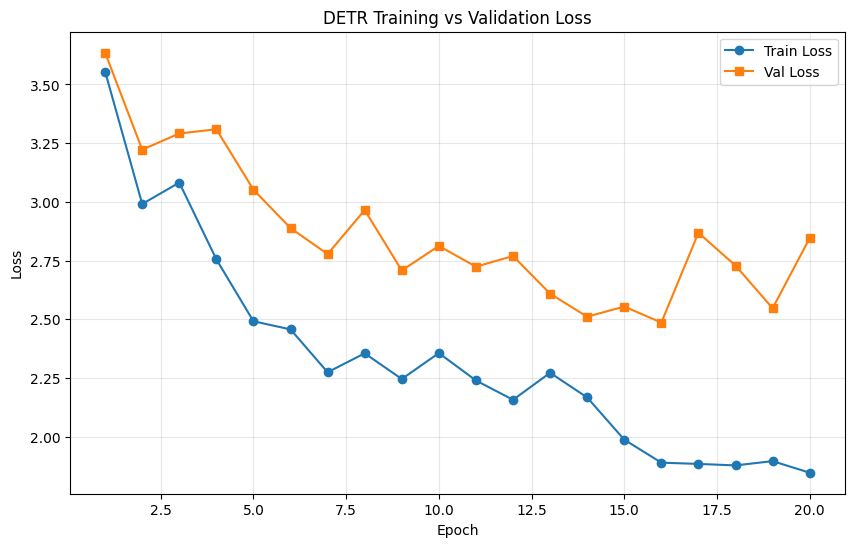

Final train loss: 1.8459
Final val loss: 2.8453
Best val loss: 2.4855 at epoch 16


In [41]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs, history["val_loss"], label="Val Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DETR Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss: {history['val_loss'][-1]:.4f}")
print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")


## 10. Load Best Model & Run Inference


In [42]:
# Reload best weightsnum_labels = num_classes_detr + 1  # +1 for background/no-object class# Load model with pretrained weights, ignoring mismatched sizes for the classification headbest_detr_model = DetrForObjectDetection.from_pretrained(    model_name,    num_labels=num_labels,  # Pass num_labels directly to from_pretrained    ignore_mismatched_sizes=True  # This will reinitialize the head)# The classification head is already reinitialized by ignore_mismatched_sizes=True# We just need to ensure the config reflects the new num_labelsbest_detr_model.config.num_labels = num_labelsbest_detr_model = best_detr_model.to(device)best_model_path = CHECKPOINT_DIR / "best_model.pt"if best_model_path.exists():    checkpoint = torch.load(best_model_path, map_location=device)    best_detr_model.load_state_dict(checkpoint['model_state_dict'])    print(f"Loaded best model from epoch {checkpoint['epoch']}")    print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")else:    print("Warning: Best model checkpoint not found. Using current model state.")    best_detr_model.load_state_dict(detr_model.state_dict())best_detr_model.eval()

RuntimeError: Error(s) in loading state_dict for Linear:
	size mismatch for bias: copying a param with shape torch.Size([92]) from checkpoint, the shape in current model is torch.Size([5]).

## 11. Visualization Helper Functions


In [ ]:
def plot_predictions_detr(model, processor, dataset, num_images=3, score_thresh=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), k=min(num_images, len(dataset)))

    for idx in indices:
        pixel_values, _ = dataset[idx]
        img_path = dataset.img_paths[idx]
        image = Image.open(img_path).convert("RGB")
        
        with torch.no_grad():
            outputs = model(pixel_values=pixel_values.unsqueeze(0).to(device))

        # Post-process outputs
        target_sizes = torch.tensor([[image.height, image.width]])
        results = processor.post_process_object_detection(outputs, threshold=score_thresh, target_sizes=target_sizes)[0]

        boxes = results["boxes"].cpu().numpy()
        scores = results["scores"].cpu().numpy()
        labels = results["labels"].cpu().numpy()

        plt.figure(figsize=(8, 8))
        plt.imshow(image)
        ax = plt.gca()

        for box, label, score in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box
            cls_idx = int(label)
            if cls_idx < 0 or cls_idx >= len(class_names):
                continue
            cls_name = class_names[cls_idx]

            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                 fill=False, color="lime", linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1-5,
                    f"{cls_name} {score:.2f}",
                    color="yellow",
                    fontsize=10,
                    bbox=dict(facecolor="black", alpha=0.5, pad=1),
                )

        plt.axis("off")
        plt.title(f"DETR predictions (idx={idx}, threshold={score_thresh})")
        plt.show()

print("Visualization function defined")


## 12. Visualize Predictions


In [ ]:
# Visualize predictions on validation images
plot_predictions_detr(best_detr_model, processor, val_dataset, num_images=3, score_thresh=0.5)


# DETR Parking Space Detection

This notebook fine-tunes DETR (Detection Transformer) ResNet50 for parking space detection using the YOLO-formatted dataset.

Features:
- Fine-tunes DETR ResNet50 on 3 classes (free, not_free, partially_free parking spaces)
- Uses existing YOLO-formatted dataset at `data/processed/yolo_parking/`
- Checkpoint saving (best model + periodic checkpoints)
- Early stopping mechanism
- Resume functionality - continue training from checkpoints
- Training and validation loss visualization
- Sample prediction visualization

**Important**: DETR uses `num_classes` = object classes only (no background). DETR adds a "no-object" class internally. So labels must be {0, 1, 2} (same as YOLO, no remapping needed).

## Installation Note

**DETR requires torchvision >= 0.12.0**, but it may not be available in all builds (especially CPU-only builds).

If you get an ImportError when importing DETR:
1. Make sure you're using a recent version of torchvision: `pip install --upgrade torchvision`
2. DETR is available in torchvision 0.12.0+ with CUDA support or standard PyPI builds
3. If DETR is still not available, you may need to install from source or use a different torchvision build

**Alternative**: If DETR is not available in your environment, you can skip this notebook and use the other detection models (SSD, Faster R-CNN, YOLO) which should work fine.



## 13. Imports & Path Setup



In [ ]:
import os
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt
import random

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.transforms.functional import convert_image_dtype
from torchvision.models.detection import detr_resnet50, Detr_ResNet50_Weights

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == "Phase 1" else (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
YOLO_ROOT = BASE_DIR / "data" / "processed" / "yolo_parking"

IMG_TRAIN = YOLO_ROOT / "images" / "train"
IMG_VAL = YOLO_ROOT / "images" / "val"
LBL_TRAIN = YOLO_ROOT / "labels" / "train"
LBL_VAL = YOLO_ROOT / "labels" / "val"

# Checkpoint directory
CHECKPOINT_DIR = BASE_DIR / "checkpoints" / "detr_parking"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("YOLO_ROOT exists:", YOLO_ROOT.exists())
print("Train images dir:", IMG_TRAIN, IMG_TRAIN.exists())
print("Train labels dir:", LBL_TRAIN, LBL_TRAIN.exists())
print("Checkpoint dir:", CHECKPOINT_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



ImportError: cannot import name 'detr_resnet50' from 'torchvision.models.detection' (c:\Harosha\George Brown\DL2\parking-vision\.venv\Lib\site-packages\torchvision\models\detection\__init__.py)

## 14. Class Names & Label Mapping

**Important**: DETR uses `num_classes` = object classes only (no background). DETR adds a "no-object" class internally. So labels must be {0, 1, 2} (same as YOLO, no remapping needed).



In [ ]:
# YOLO-style class names from data.yaml
class_names = [
    "free_parking_space",
    "not_free_parking_space",
    "partially_free_parking_space",
]

num_classes_detr = len(class_names)  # DETR: object classes only (no background)

print("Classes:", class_names)
print("num_classes_detr (for DETR):", num_classes_detr)
print("\nNote: DETR adds 'no-object' class internally, so labels must be {0, 1, 2}")

# YOLO class ids (0,1,2) -> DETR labels (0,1,2), NO background index here
# Actually, same mapping - no remapping needed!
yolo_to_detr = {0: 0, 1: 1, 2: 2}

print("\nLabel mapping (same as YOLO):")
print("YOLO class 0 -> DETR class 0 (free_parking_space)")
print("YOLO class 1 -> DETR class 1 (not_free_parking_space)")
print("YOLO class 2 -> DETR class 2 (partially_free_parking_space)")



## 15. Custom Dataset for YOLO -> DETR

Converts YOLO format annotations to DETR format (bounding boxes in pixel coordinates). Labels are {0, 1, 2} - same as YOLO.



In [ ]:
class YoloDetectionDatasetDetr(Dataset):
    def __init__(self, img_dir: Path, lbl_dir: Path, yolo_to_detr_map: dict):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.yolo_to_detr = yolo_to_detr_map

        # collect image paths
        exts = (".jpg", ".jpeg", ".png")
        self.img_paths = [p for p in sorted(img_dir.rglob("*")) if p.suffix.lower() in exts]

        if len(self.img_paths) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        # labels file same stem, .txt
        lbl_path = self.lbl_dir / (img_path.stem + ".txt")

        # read image [C,H,W] in uint8, convert to float [0,1]
        img = read_image(str(img_path))  # shape: (C,H,W) - could be 1, 3, or 4 channels
        
        # Handle different channel counts
        C, H, W = img.shape
        if C == 1:
            # Grayscale - convert to RGB by repeating channels
            img = img.repeat(3, 1, 1)
        elif C == 4:
            # RGBA - drop alpha channel, keep RGB
            img = img[:3, :, :]
        elif C != 3:
            # Unexpected channel count
            raise ValueError(f"Unexpected number of channels: {C} for image {img_path}")
        
        img = convert_image_dtype(img, dtype=torch.float32)

        _, H, W = img.shape

        boxes = []
        labels = []

        if lbl_path.exists():
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_yolo = int(parts[0])
                    xc_n, yc_n, w_n, h_n = map(float, parts[1:])

                    # convert YOLO normalized to pixel coords
                    xc = xc_n * W
                    yc = yc_n * H
                    bw = w_n * W
                    bh = h_n * H

                    x_min = xc - bw / 2.0
                    y_min = yc - bh / 2.0
                    x_max = xc + bw / 2.0
                    y_max = yc + bh / 2.0

                    # clip to image bounds
                    x_min = max(0.0, x_min)
                    y_min = max(0.0, y_min)
                    x_max = min(float(W), x_max)
                    y_max = min(float(H), y_max)

                    if x_max <= x_min or y_max <= y_min:
                        continue

                    # remap class id for DETR (actually same mapping)
                    if cls_yolo not in self.yolo_to_detr:
                        continue
                    cls_detr = self.yolo_to_detr[cls_yolo]

                    boxes.append([x_min, y_min, x_max, y_max])
                    labels.append(cls_detr)

        if len(boxes) == 0:
            # if no boxes, create empty target
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
        }

        return img, target

train_dataset = YoloDetectionDatasetDetr(IMG_TRAIN, LBL_TRAIN, yolo_to_detr)
val_dataset = YoloDetectionDatasetDetr(IMG_VAL, LBL_VAL, yolo_to_detr)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))



In [ ]:
def detection_collate_fn(batch):
    images = []
    targets = []
    for img, tgt in batch:
        images.append(img)
        targets.append(tgt)
    return images, targets

BATCH_SIZE = 4  # DETR is fairly heavy; keep batch small

# Note: num_workers=0 on Windows to avoid multiprocessing issues
# Set to 2-4 on Linux/Mac for faster data loading
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Windows compatibility - use 0, set to 2-4 on Linux/Mac
    collate_fn=detection_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Windows compatibility - use 0, set to 2-4 on Linux/Mac
    collate_fn=detection_collate_fn,
)

# quick sanity check
imgs, tgts = next(iter(train_loader))
print("Batch len:", len(imgs), "Image shape:", imgs[0].shape)
print("Targets sample - boxes shape:", tgts[0]["boxes"].shape, "labels:", tgts[0]["labels"])



## 16. Load DETR Model (Pretrained) & Configure Training

We'll use `detr_resnet50` from torchvision.models.detection.

**Important**: DETR's `num_classes` = object classes only (no background). DETR adds "no-object" class internally.



In [ ]:
# Load pretrained DETR model
weights = Detr_ResNet50_Weights.DEFAULT
detr_model = detr_resnet50(
    weights=weights,
    num_classes=num_classes_detr,  # 3 classes; DETR adds 'no-object' internally
).to(device)

# put model in training mode
detr_model.train()

# Setup optimizer
params = [p for p in detr_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

print("DETR Model loaded and configured")
print(f"Total parameters: {sum(p.numel() for p in detr_model.parameters() if p.requires_grad):,}")
print(f"num_classes={num_classes_detr} (DETR will add 'no-object' class internally)")



## 17. Training Configuration

Configure training parameters including epochs, early stopping, and checkpoint settings.



In [ ]:
# Training hyperparameters
NUM_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for this many epochs
MIN_DELTA = 0.001  # Minimum change to qualify as improvement
CHECKPOINT_EVERY = 5  # Save checkpoint every N epochs

print("Training Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Early Stopping Patience: {EARLY_STOPPING_PATIENCE} epochs")
print(f"  Min Delta: {MIN_DELTA}")
print(f"  Checkpoint Every: {CHECKPOINT_EVERY} epochs")



### 6.1 Optional: Reset Checkpoints (Start Fresh)

Run this cell only if you want to delete all checkpoints and start training from scratch.



In [ ]:
# Uncomment the lines below to delete all checkpoints and start fresh
# import shutil
# if CHECKPOINT_DIR.exists():
#     for checkpoint_file in CHECKPOINT_DIR.glob("*.pt"):
#         checkpoint_file.unlink()
#         print(f"Deleted: {checkpoint_file.name}")
#     print("All checkpoints deleted. Training will start from scratch.")
# else:
#     print("No checkpoints directory found.")




## 18. Training Functions

Functions for training one epoch and evaluating the model.



In [ ]:
def train_one_epoch_detr(model, data_loader, optimizer, device):
    model.train()
    running_loss = 0.0
    num_batches = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()
        num_batches += 1

    return running_loss / max(1, num_batches)

@torch.no_grad()
def evaluate_detr(model, data_loader, device):
    # Keep model in training mode to get losses (not predictions)
    # but use no_grad() to prevent gradient computation
    model.train()
    running_loss = 0.0
    num_batches = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        running_loss += losses.item()
        num_batches += 1

    return running_loss / max(1, num_batches)

print("Training functions defined")



## 19. Training Loop with Early Stopping, Checkpoints, and Resume

**Resume Functionality**: If a checkpoint exists, training will automatically resume from the last saved epoch. Simply increase `NUM_EPOCHS` to continue training beyond the checkpoint. To start fresh, delete the checkpoint files.



In [ ]:
# Initialize training state
start_epoch = 1
best_val_loss = float("inf")
history = {
    "train_loss": [],
    "val_loss": [],
}
patience_counter = 0
best_epoch = 0

# Try to load the best model checkpoint first (most recent training)
best_model_path = CHECKPOINT_DIR / "best_model.pt"
if best_model_path.exists():
    print(f"Found existing checkpoint: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    
    # Load model state
    detr_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Restore training state
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', checkpoint.get('val_loss', float('inf')))
    best_epoch = checkpoint.get('best_epoch', checkpoint['epoch'])
    history = checkpoint.get('history', history)
    patience_counter = checkpoint.get('patience_counter', 0)
    
    print(f"Resuming training from epoch {start_epoch}")
    print(f"Previous best: Val Loss = {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"Previous history: {len(history['train_loss'])} epochs completed")
    
    # If we're already past NUM_EPOCHS, inform user
    if start_epoch > NUM_EPOCHS:
        print(f"\nNote: Checkpoint is at epoch {start_epoch-1}, but NUM_EPOCHS={NUM_EPOCHS}.")
        print("Increase NUM_EPOCHS to continue training beyond the checkpoint.")
else:
    print("No existing checkpoint found. Starting fresh training.")

start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    train_loss = train_one_epoch_detr(detr_model, train_loader, optimizer, device)
    val_loss = evaluate_detr(detr_model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Check for improvement
    improved = False
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        improved = True
        
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': detr_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch,
            'patience_counter': patience_counter,
            'history': history,
        }, best_model_path)
        print(f"  -> New best model saved! (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1

    # Save periodic checkpoint
    if epoch % CHECKPOINT_EVERY == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': detr_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'history': history,
            'best_epoch': best_epoch,
        }, checkpoint_path)
        print(f"  -> Checkpoint saved: {checkpoint_path.name}")

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}{' *' if improved else ''}")

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered! No improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
        break

end_time = time.time()
print(f"\nTraining finished in {(end_time - start_time)/60:.2f} minutes.")
print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")



In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs, history["val_loss"], label="Val Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DETR Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss: {history['val_loss'][-1]:.4f}")
print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")



## 20. Load Best Model & Run Inference on Validation Images

Load the best model and visualize predictions on validation images.

**Note**: DETR outputs:
- `pred_logits`: [num_queries, num_classes + 1] (last dim = "no-object")
- `pred_boxes`: [num_queries, 4] in normalized cx, cy, w, h in [0,1]



In [ ]:
# Reload best weights
best_detr_model = detr_resnet50(
    weights=None,
    num_classes=num_classes_detr,
).to(device)

best_model_path = CHECKPOINT_DIR / "best_model.pt"
if best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=device)
    best_detr_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
else:
    print("Warning: Best model checkpoint not found. Using current model state.")
    best_detr_model.load_state_dict(detr_model.state_dict())

best_detr_model.eval()



### 10.1 Helper Function: Convert cxcywh to xyxy

DETR outputs boxes in normalized center coordinates (cx, cy, w, h), so we need to convert to (x1, y1, x2, y2) for visualization.



In [ ]:
def cxcywh_to_xyxy(boxes_cxcywh, img_w, img_h):
    """
    Convert boxes from normalized center coordinates (cx, cy, w, h) to pixel coordinates (x1, y1, x2, y2).
    
    Args:
        boxes_cxcywh: Tensor [N,4] with (cx, cy, w, h) normalized [0,1]
        img_w: Image width in pixels
        img_h: Image height in pixels
    
    Returns:
        Tensor [N,4] with (x1, y1, x2, y2) in pixels
    """
    cx = boxes_cxcywh[:, 0] * img_w
    cy = boxes_cxcywh[:, 1] * img_h
    w = boxes_cxcywh[:, 2] * img_w
    h = boxes_cxcywh[:, 3] * img_h
    
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    
    return torch.stack([x1, y1, x2, y2], dim=1)

print("Helper function defined")



### 10.2 Visualization Helper Function



In [ ]:
def plot_predictions_detr(model, dataset, num_images=3, score_thresh=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), k=min(num_images, len(dataset)))

    for idx in indices:
        img, _ = dataset[idx]
        _, H, W = img.shape
        
        img_gpu = img.to(device).unsqueeze(0)

        with torch.no_grad():
            outputs = model(img_gpu)[0]  # dict for single image

        logits = outputs["pred_logits"]      # [num_queries, num_classes+1]
        boxes = outputs["pred_boxes"]        # [num_queries, 4] (cx,cy,w,h normalized)

        # Compute class probabilities, ignoring 'no-object' (last column)
        probs = logits.softmax(-1)[..., :-1]  # [num_queries, num_classes]
        scores, labels = probs.max(-1)       # [num_queries], [num_queries]

        # Filter by score threshold
        keep = scores > score_thresh
        scores = scores[keep].cpu().numpy()
        labels = labels[keep].cpu().numpy()
        boxes = boxes[keep]

        if boxes.numel() == 0:
            print(f"No detections above threshold {score_thresh} for idx={idx}")
        else:
            # Convert cxcywh (normalized) to xyxy (pixels)
            boxes_xyxy = cxcywh_to_xyxy(boxes, W, H).cpu().numpy()

            # Convert image to numpy for plotting
            img_np = img.cpu().numpy().transpose(1, 2, 0)  # [H,W,C]
            img_np = np.clip(img_np, 0, 1)

            plt.figure(figsize=(8, 8))
            plt.imshow(img_np)
            ax = plt.gca()

            for (x1, y1, x2, y2), label, score in zip(boxes_xyxy, labels, scores):
                cls_idx = int(label)
                if cls_idx < 0 or cls_idx >= len(class_names):
                    continue
                cls_name = class_names[cls_idx]

                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                     fill=False, color="lime", linewidth=2)
                ax.add_patch(rect)
                ax.text(
                    x1, y1 - 5,
                    f"{cls_name} {score:.2f}",
                    color="yellow",
                    fontsize=10,
                    bbox=dict(facecolor="black", alpha=0.5, pad=1),
                )

            plt.axis("off")
            plt.title(f"DETR predictions (idx={idx}, threshold={score_thresh})")
            plt.show()

print("Visualization function defined")



### 10.3 Visualize Predictions



In [ ]:
# Visualize predictions on validation images
plot_predictions_detr(best_detr_model, val_dataset, num_images=3, score_thresh=0.5)



## 21. (Optional) Rough FPS Measurement

Measure inference speed for comparison with SSD, Faster R-CNN, and YOLO.



In [ ]:
@torch.no_grad()
def measure_fps_detr(model, dataset, device, num_samples=30):
    model.eval()
    t0 = time.time()
    count = 0
    for i in range(num_samples):
        img, _ = dataset[i % len(dataset)]
        img_gpu = img.to(device).unsqueeze(0)
        _ = model(img_gpu)
        count += 1
    t1 = time.time()
    fps = count / (t1 - t0)
    return fps

fps_detr = measure_fps_detr(best_detr_model, val_dataset, device, num_samples=20)
print(f"Approx DETR FPS on {device}: {fps_detr:.2f} frames/s")

